# Homework
### Silvia Parente
#### due May 1st

Use SDSS DR18 SQL search to find all galaxies which have only
the narrow emission lines (FWHM<500 km/s), high median signal
to noise ratio in g band (S/N>40), and fluxes of lines: [O III] 5007,
Hβ, Hα and [N II] 6583 larger than 5 e-17 erg/s/cm^2. Set criteria
so that the fluxes are larger than errors in flux multiplied with 5 in
order to get good results. SQL output should be the fluxes of
these lines. 

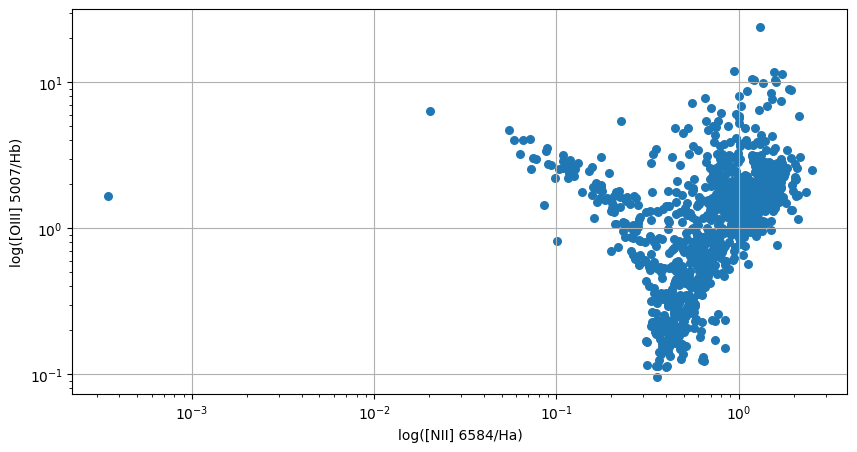

In [ ]:
''' 
SELECT 
    s.plate, s.mjd, s.fiberid,
    g.oiii_5007_flux, g.h_beta_flux, g.h_alpha_flux, g.nii_6584_flux, 
    i.e_bv_sfd,
    g.oiii_5007_flux_err, g.h_beta_flux_err, g.h_alpha_flux_err, g.nii_6584_flux_err,
    (g.oiii_5007_flux / g.h_beta_flux) AS ratio_oiii_hb,
    (g.nii_6584_flux / g.h_alpha_flux) AS ratio_nii_ha
FROM SpecObj AS s
JOIN GalSpecLine AS g ON s.specobjid = g.specobjid
JOIN GalSpecInfo AS i ON s.specobjid = i.specobjid
WHERE 
    s.class = 'GALAXY'
    AND s.snmedian_g > 40
    AND g.sigma_balmer < 212.3
    AND g.sigma_forbidden < 212.3
    AND g.oiii_5007_flux > 5
    AND g.h_beta_flux > 5
    AND g.h_alpha_flux > 5
    AND g.nii_6584_flux > 5
    AND g.oiii_5007_flux > (5 * g.oiii_5007_flux_err)
    AND g.h_beta_flux > (5 * g.h_beta_flux_err)
    AND g.h_alpha_flux > (5 * g.h_alpha_flux_err)
    AND g.nii_6584_flux > (5 * g.nii_6584_flux_err)
'''

import pandas as pd
import matplotlib.pyplot as plt

df1=pd.read_csv('ex1.csv', comment='#')
#the error i had last time was that the first row of the table was 'Table #1'
plt.figure(figsize=(10, 5))
plt.scatter(df1['ratio_nii_ha'],df1['ratio_oiii_hb'], s=30)
plt.xlabel('log([NII] 6584/Ha)')
plt.ylabel('log([OIII] 5007/Hb)')
plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.show()


For the sample of galaxies selected from SDSS database in Part I, find the corresponding WISE colors using WISE fluxes from Cross-identifications link:

https://skyserver.sdss.org/dr14/en/help/docs/realquery.aspx#wisexmatch 

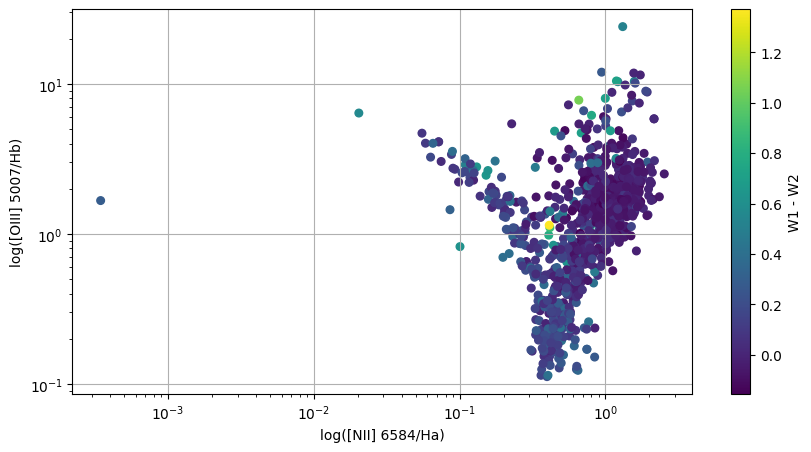

In [2]:
''' 
SELECT 
    s.plate, s.mjd, s.fiberid,
    g.oiii_5007_flux, g.h_beta_flux, g.h_alpha_flux, g.nii_6584_flux, 
    w.w1mpro, w.w2mpro, w.w3mpro,
    (w.w1mpro - w.w2mpro) as w1_w2,
    (w.w2mpro - w.w3mpro) as w2_w3,
    (g.oiii_5007_flux / NULLIF(g.h_beta_flux, 0)) AS ratio_oiii_hb,
    (g.nii_6584_flux / NULLIF(g.h_alpha_flux, 0)) AS ratio_nii_ha
FROM SpecObj AS s
JOIN GalSpecLine AS g ON s.specobjid = g.specobjid
JOIN GalSpecInfo AS i ON s.specobjid = i.specobjid
JOIN PhotoTag AS p ON s.bestobjid = p.objid
JOIN wise_xmatch AS x ON p.objid = x.sdss_objid
JOIN wise_allsky AS w ON x.wise_cntr = w.cntr
WHERE 
    s.class = 'GALAXY'
    AND s.snmedian_g > 40
    AND g.sigma_balmer < 212.3
    AND g.sigma_forbidden < 212.3
    AND g.oiii_5007_flux > 5
    AND g.h_beta_flux > 5
    AND g.h_alpha_flux > 5
    AND g.nii_6584_flux > 5
    AND g.oiii_5007_flux > (5 * g.oiii_5007_flux_err)
    AND g.h_beta_flux > (5 * g.h_beta_flux_err)
    AND g.h_alpha_flux > (5 * g.h_alpha_flux_err)
    AND g.nii_6584_flux > (5 * g.nii_6584_flux_err)
    AND w.w1mpro > 0 AND w.w2mpro > 0
'''

df=pd.read_csv('ex2.csv')
plt.figure(figsize=(10, 5))
sc = plt.scatter(df['ratio_nii_ha'], df['ratio_oiii_hb'], c=df['w1_w2'], s=30)
cbar = plt.colorbar(sc)
cbar.set_label('W1 - W2')
plt.xlabel('log([NII] 6584/Ha)')
plt.ylabel('log([OIII] 5007/Hb)')
plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.show()

Assign classes (AGN & (u)LIRGS, Spheroids, Intermediate disks and SF disks) to all objects in the sample using the thresholds from the image on the bottom right (dashed lines). How do these classes compare to ones obtained using BPT diagram from Part I?

In [3]:
def classify(row):
    w12 = row['w1_w2']
    w23 = row['w2_w3']
    if w12 >= 0.8:
        return 'AGN'
    elif w12 < 0.5 and w23 < 1.5:
        return 'spheroids'
    elif 1.5 <= w23 < 3.0 and w12 < 0.8:
        return 'intermediate disks'
    elif w23 >= 3.0 and w12 < 0.8:
        return 'SF disks'
    else:
        return 'other'
    
df['wise_class'] = df.apply(classify, axis=1)


Locate one random object on the WISE color-color plot having W1-W2>=0.8 (Assef et al. 2013) and address the following:

- Where is the object located in this plot? Mark it clearly on the graph.

- Does it agree with the optical classification from BPT diagram?

- Draw some conclusions about the type of AGN using the WISE color-color plot.

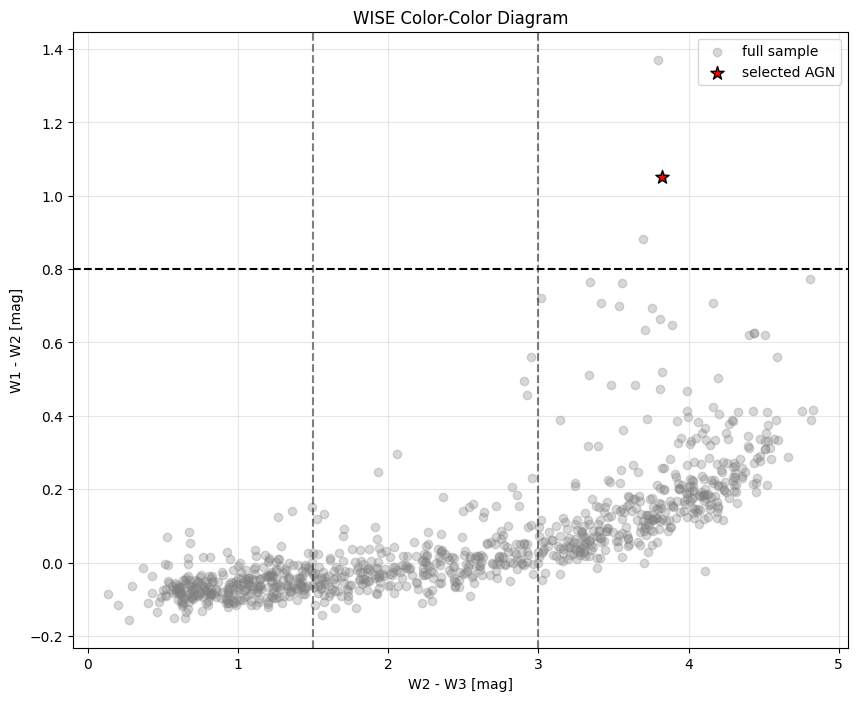

object: Plate 2117, MJD 54115, Fiber 351
WISE color W1-W2: 1.05


In [4]:
import numpy as np

agn_candidates = df[df['w1_w2'] >= 0.8]
random_agn = agn_candidates.sample(n=1).iloc[0]

plt.figure(figsize=(10, 8))

plt.scatter(df['w2_w3'], df['w1_w2'], c='gray', alpha=0.3, label='full sample')
plt.scatter(random_agn['w2_w3'], random_agn['w1_w2'], 
            c='red', s=100, edgecolors='black', marker='*', label='selected AGN')

plt.axhline(0.8, color='black', linestyle='--') 
plt.axvline(1.5, color='black', linestyle='--', alpha=0.5)
plt.axvline(3.0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('W2 - W3 [mag]')
plt.ylabel('W1 - W2 [mag]')
plt.title('WISE Color-Color Diagram')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"object: Plate {random_agn['plate']}, MJD {random_agn['mjd']}, Fiber {random_agn['fiberid']}")
print(f"WISE color W1-W2: {random_agn['w1_w2']:.2f}")

I just have three objects in the w1-w2>0.8 area and they all are in the w2-w3>3 side. They will randomly be selected every time.

- The objects are in the top-right of the plot, in the AGN area. The infrared light is not coming from stars, but from the thermal emission of the dusty torus surrounding a supermassive black hole.

- They agree with the BPT classification: "standard AGN". Both the gas (optical) and the dust (IR) are being heated by the black hole.
